In [18]:
# Importing libraries
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [19]:
# Linear Regression

class LinearRegression():

    def __init__(self, learning_rate, iterations):

        self.learning_rate = learning_rate
        self.iterations = iterations

    # Function for model training

    def fit(self, X, Y):

        # no_of_training_examples, no_of_features

        self.m, self.n = X.shape

        # weight initialization

        self.W = np.zeros(self.n)
        self.b = 0

        self.X = X
        self.Y = Y

        # gradient descent learning

        for i in range(self.iterations):

            self.update_weights()

        return self

    # Helper function to update weights in gradient descent

    def update_weights(self):

        Y_pred = self.predict(self.X)

        # calculate gradients

        dW = -(2 * (self.X.T).dot(self.Y - Y_pred)) / self.m

        db = -2 * np.sum(self.Y - Y_pred) / self.m

        # update weights

        self.W = self.W - self.learning_rate * dW

        self.b = self.b - self.learning_rate * db

        return self

    # Hypothetical function h(x)

    def predict(self, X):

        return X.dot(self.W) + self.b

In [ ]:
# Importing dataset
# df = pd.read_csv( "salary_data.csv" )
df = pd.read_csv("../../src/data/Salary_Data.csv")

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [34]:
# Independent and dependent variables

X = df.iloc[:, :-1].values
Y = df.iloc[:, 1].values

print(X[:5])
print(Y[:5])

[[1.1]
 [1.3]
 [1.5]
 [2. ]
 [2.2]]
[39343. 46205. 37731. 43525. 39891.]


In [35]:
# Splitting dataset into train and test set

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=1/3, random_state=0
)

In [36]:
# Model training

model = LinearRegression(
    iterations=1000,
    learning_rate=0.01
)

model.fit(X_train, Y_train)

In [37]:
# Prediction on test set

Y_pred = model.predict(X_test)

print("Predicted values ", np.round(Y_pred[:3], 2))
print("Real values      ", Y_test[:3])

print("Trained W        ", round(model.W[0], 2))
print("Trained b        ", round(model.b, 2))

Predicted values  [ 40594.69 123305.18  65031.88]
Real values       [ 37731. 122391.  57081.]
Trained W         9398.92
Trained b         26496.31


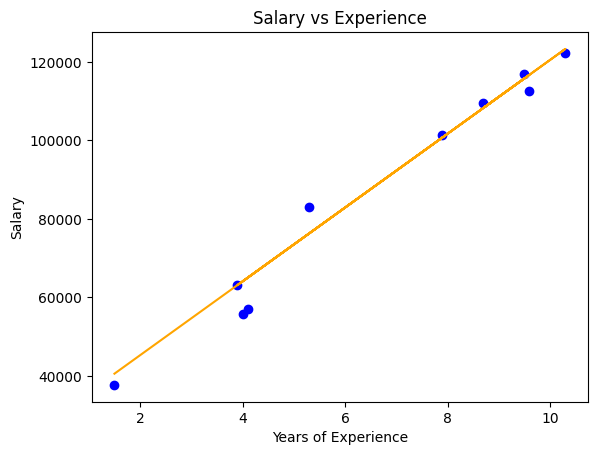

In [38]:
# Visualization on test set

plt.scatter(X_test, Y_test, color='blue')

plt.plot(X_test, Y_pred, color='orange')

plt.title('Salary vs Experience')

plt.xlabel('Years of Experience')

plt.ylabel('Salary')

plt.show()